In [1]:
library(ggplot2)
setwd("/staging/leuven/stg_00041/Bradley/XCI.Amitesh/IFquantification")

In [2]:
#function to load all files when given a folder
loadIFlineInfo <- function(folderName){
    fileNames <-list.files(path=folderName)
    lineFiles <- list()
    
    for(i in 1:length(fileNames)){
     lineFiles[[i]] <- read.table(paste(c(folderName, fileNames[i]), collapse="/"), h=T, sep="\t")  
        
    }
    
    return(lineFiles)
}


In [3]:
calculateColZscores <- function(inputFrame, colOfPeak=2, colOfCompare=3, highThreshold=0.5, lowThreshold=0.25){
    maxPeak <- max(inputFrame[,colOfPeak])
    SDlow <- sd(inputFrame[which(inputFrame[,colOfPeak]<(lowThreshold*maxPeak)),colOfCompare])
    aveLow <- mean(inputFrame[which(inputFrame[,colOfPeak]<(lowThreshold*maxPeak)),colOfCompare])
    aveHigh <-  mean(inputFrame[which(inputFrame[,colOfPeak]>(highThreshold*maxPeak)),colOfCompare])
    return((aveHigh-aveLow)/SDlow)
}

In [4]:
allDirectories <- list.dirs("/staging/leuven/stg_00041/Bradley/XCI.Amitesh/IFquantification")[-1]

In [5]:
allDirectories

[1] "/staging/leuven/stg_00041/Bradley/XCI.Amitesh/IFquantification/H9 EXMC"         
[2] "/staging/leuven/stg_00041/Bradley/XCI.Amitesh/IFquantification/H9 Naive"        
[3] "/staging/leuven/stg_00041/Bradley/XCI.Amitesh/IFquantification/H9 TSC"          
[4] "/staging/leuven/stg_00041/Bradley/XCI.Amitesh/IFquantification/New Sigma WT TSC"
[5] "/staging/leuven/stg_00041/Bradley/XCI.Amitesh/IFquantification/Old Sigma WT TSC"
[6] "/staging/leuven/stg_00041/Bradley/XCI.Amitesh/IFquantification/Sigma WT EXMC"   
[7] "/staging/leuven/stg_00041/Bradley/XCI.Amitesh/IFquantification/Sigma WT Naive"

In [6]:
allData <- vector(mode="list", length=length(allDirectories))
for(i in 1:length(allData)){
 allData[[i]] <- list(folder=allDirectories[i], files=loadIFlineInfo(allDirectories[i]))   
}


In [7]:
allZscores <- data.frame(cellType=NA, Zscore=NA)[0,]
for(i in 1:length(allData)){
 
    #will need to adjust the 8 if you change the directory as this is cutting off the rest of the path and only taking folder name,
    allZscores <- rbind(allZscores, data.frame(cellType=strsplit(allData[[i]]$folder, split="/")[[1]][8],
                                              Zscore=unlist(lapply(allData[[i]]$files, calculateColZscores, lowThreshold=0.6, highThreshold=0.65))))
}


In [8]:
strsplit(allData[[1]]$folder, split="/")[[1]][8]

[1] "H9 EXMC"

In [9]:
calculateColZscores <- function(inputFrame, colOfPeak=2, colOfCompare=3, widthOfPeaks=0.5, widthOutsidePeaks=1){
    inputFrame <- inputFrame[c(-1:-2, -nrow(inputFrame):-(nrow(inputFrame)-1)),]
    peakLoc <- inputFrame[which.max(inputFrame[,colOfPeak]),1]
    peakMax <- max(inputFrame[,colOfPeak])
    SDlow <- sd(inputFrame[((inputFrame[,1]<peakLoc-widthOutsidePeaks |  inputFrame[,1]>peakLoc+widthOutsidePeaks) & inputFrame[,colOfPeak]<0.60*peakMax),colOfCompare])
    aveLow <- mean(inputFrame[((inputFrame[,1]<peakLoc-widthOutsidePeaks |  inputFrame[,1]>peakLoc+widthOutsidePeaks)& inputFrame[,colOfPeak]<0.60*peakMax),colOfCompare])
    aveHigh <-  mean(inputFrame[((inputFrame[,1]>peakLoc-widthOfPeaks &  inputFrame[,1]<peakLoc+widthOfPeaks) & inputFrame[,colOfPeak]>0.65*peakMax),colOfCompare])
    
    
    return((aveHigh-aveLow)/SDlow)
}

In [10]:
allZscores <- data.frame(cellType=NA, Zscore=NA)[0,]
for(i in 1:length(allData)){
 
    #will need to adjust the 8 if you change the directory as this is cutting off the rest of the path and only taking folder name,
    allZscores <- rbind(allZscores, data.frame(cellType=strsplit(allData[[i]]$folder, split="/")[[1]][8],
                                              Zscore=unlist(lapply(allData[[i]]$files, calculateColZscores, widthOfPeaks=0.5, widthOutsidePeaks=1))))
}


In [11]:
unique(allZscores$cellType)

[1] "H9 EXMC"          "H9 Naive"         "H9 TSC"           "New Sigma WT TSC"
[5] "Old Sigma WT TSC" "Sigma WT EXMC"    "Sigma WT Naive"

In [12]:
allZscores$cellType <- factor(allZscores$cellType, levels=c("Sigma WT Naive", "H9 Naive", "Sigma WT EXMC","H9 EXMC", "Old Sigma WT TSC", "New Sigma WT TSC", "H9 TSC"))

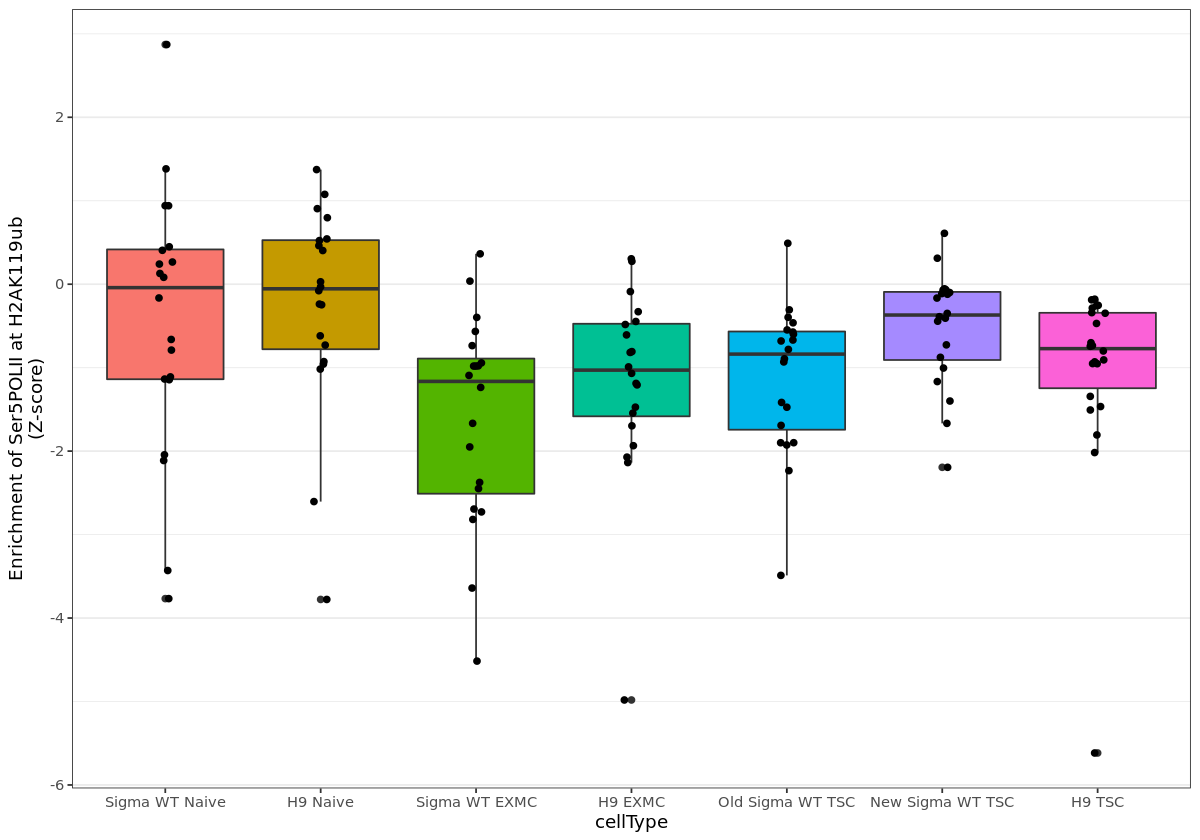

In [13]:
options(repr.plot.width=10)
ggplot(allZscores, aes(x=cellType, y=Zscore, fill=cellType))+geom_boxplot(notch=F)+theme_bw()+geom_jitter(aes(), width = 0.05)+
ylab("Enrichment of Ser5POLII at H2AK119ub\n(Z-score)")+theme(panel.grid.major.x=element_blank(), legend.position="none")#+coord_cartesian(ylim=c(-4, 4))

In [14]:
allZscores$changeCellType <- as.character(allZscores$cellType)

allZscores$changeCellType[which(allZscores$changeCellType=="Old Sigma WT TSC")] <- "Sigma WT TSC"
#llZscores$changeCellType[which(allZscores$changeCellType=="New Sigma WT TSC")] <- "Sigma WT TSC"
allZscores$changeCellType <- factor(allZscores$changeCellType, levels=c("Sigma WT Naive", "H9 Naive", "Sigma WT EXMC", "H9 EXMC", "Sigma WT TSC", "H9 TSC"))

In [187]:
pdf("/data/leuven/343/vsc34313/jupyter_notebooks/XCI/bulkRNAseq/figs.bulkRNAseq4Amitesh/IFquantification.H9.pdf", width=4, height=3)
ggplot(allZscores[which(!allZscores$changeCellType%in%c("New Sigma WT TSC", "Sigma WT Naive", "Sigma WT EXMC", "Sigma WT TSC", NA)),], aes(x=changeCellType, y=Zscore, fill=cellType))+geom_boxplot(notch=F)+theme_bw()+geom_jitter(aes(), width = 0.05)+
ylab("Enrichment of Ser5POLII at H2AK119ub\n(Z-score)")+theme(panel.grid.major.x=element_blank(), legend.position="none", text=element_text(size=8))+xlab("Cell Type")+
coord_cartesian(ylim=c(-6, 3))
dev.off()

pdf("/data/leuven/343/vsc34313/jupyter_notebooks/XCI/bulkRNAseq/figs.bulkRNAseq4Amitesh/IFquantification.Sigma.pdf", width=4, height=3)
ggplot(allZscores[which(!allZscores$changeCellType%in%c("New Sigma WT TSC", "H9 Naive", "H9 EXMC", "H9 TSC", NA)),], aes(x=changeCellType, y=Zscore, fill=cellType))+geom_boxplot(notch=F)+theme_bw()+geom_jitter(aes(), width = 0.05)+
ylab("Enrichment of Ser5POLII at H2AK119ub\n(Z-score)")+theme(panel.grid.major.x=element_blank(), legend.position="none", text=element_text(size=8))+xlab("Cell Type")+
coord_cartesian(ylim=c(-6, 3))
dev.off()

png 
  2

png 
  2

In [188]:
pdf("/data/leuven/343/vsc34313/jupyter_notebooks/XCI/bulkRNAseq/figs.bulkRNAseq4Amitesh/IFquantification.pdf", width=4, height=3)
ggplot(allZscores[which(allZscores$changeCellType!="New Sigma WT TSC"),], aes(x=changeCellType, y=Zscore, fill=cellType))+geom_boxplot(notch=F)+theme_bw()+geom_jitter(aes(), width = 0.05)+
ylab("Enrichment of Ser5POLII at H2AK119ub\n(Z-score)")+theme(panel.grid.major.x=element_blank(), legend.position="none", text=element_text(size=8))+xlab("Cell Type")+
coord_cartesian(ylim=c(-6, 3))
dev.off()

png 
  2

In [15]:
wilcox.test(x = allZscores$Zscore[which(allZscores$cellType=="Sigma WT EXMC")], 
            y=allZscores$Zscore[which(allZscores$cellType=="Sigma WT Naive")])

wilcox.test(x = allZscores$Zscore[which(allZscores$cellType=="Old Sigma WT TSC")], 
            y=allZscores$Zscore[which(allZscores$cellType=="Sigma WT Naive")])

wilcox.test(x = allZscores$Zscore[which(allZscores$cellType=="New Sigma WT TSC")], 
            y=allZscores$Zscore[which(allZscores$cellType=="Sigma WT Naive")])

wilcox.test(x = allZscores$Zscore[which(allZscores$changeCellType=="Sigma WT TSC")], 
            y=allZscores$Zscore[which(allZscores$cellType=="Sigma WT Naive")])


	Wilcoxon rank sum exact test

data:  allZscores$Zscore[which(allZscores$cellType == "Sigma WT EXMC")] and allZscores$Zscore[which(allZscores$cellType == "Sigma WT Naive")]
W = 108, p-value = 0.01217
alternative hypothesis: true location shift is not equal to 0



	Wilcoxon rank sum exact test

data:  allZscores$Zscore[which(allZscores$cellType == "Old Sigma WT TSC")] and allZscores$Zscore[which(allZscores$cellType == "Sigma WT Naive")]
W = 135, p-value = 0.08098
alternative hypothesis: true location shift is not equal to 0



	Wilcoxon rank sum exact test

data:  allZscores$Zscore[which(allZscores$cellType == "New Sigma WT TSC")] and allZscores$Zscore[which(allZscores$cellType == "Sigma WT Naive")]
W = 171, p-value = 0.445
alternative hypothesis: true location shift is not equal to 0



	Wilcoxon rank sum exact test

data:  allZscores$Zscore[which(allZscores$changeCellType == "Sigma WT TSC")] and allZscores$Zscore[which(allZscores$cellType == "Sigma WT Naive")]
W = 135, p-value = 0.08098
alternative hypothesis: true location shift is not equal to 0


In [169]:
wilcox.test(x = allZscores$Zscore[which(allZscores$cellType=="H9 EXMC")], 
            y=allZscores$Zscore[which(allZscores$cellType=="H9 Naive")])

wilcox.test(x = allZscores$Zscore[which(allZscores$cellType=="H9 TSC")], 
            y=allZscores$Zscore[which(allZscores$cellType=="H9 Naive")])


	Wilcoxon rank sum exact test

data:  allZscores$Zscore[which(allZscores$cellType == "H9 EXMC")] and allZscores$Zscore[which(allZscores$cellType == "H9 Naive")]
W = 92, p-value = 0.002915
alternative hypothesis: true location shift is not equal to 0



	Wilcoxon rank sum exact test

data:  allZscores$Zscore[which(allZscores$cellType == "H9 TSC")] and allZscores$Zscore[which(allZscores$cellType == "H9 Naive")]
W = 108, p-value = 0.004185
alternative hypothesis: true location shift is not equal to 0
